Run this once if your environment is missing packages.

In [1]:
# Pinned to the same versions as requirements.txt ("the versions the workflow was
# validated with") so this cell and a pip install -r give identical environments.
%pip install -q pandas==3.0.3 numpy==2.5.0 scikit-learn==1.9.0 xgboost==3.3.0 lightgbm==4.6.0 catboost==1.2.10 matplotlib==3.11.0 optuna==4.9.0


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Optional: preview the prebuilt feature table if your local pyarrow version can read it.
# The model demo below does not depend on this parquet file; it reads the CSV directly.
import pandas as pd

features_path = "data/features.parquet"
try:
    print(f"Loading optional feature data from {features_path}")
    features_preview = pd.read_parquet(features_path)
    print(f"Loaded {len(features_preview)} rows with columns: {list(features_preview.columns)}")
    display(features_preview.head())
except Exception as exc:
    print(f"Skipping optional parquet preview: {exc}")
    print("Continue to the next cell; the model workflow uses the CSV file directly.")


Loading optional feature data from data/features.parquet
Skipping optional parquet preview: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.
Continue to the next cell; the model workflow uses the CSV file directly.


## Heat-index forecasting: model testing workflow

The target is **tomorrow's heat index**, predicted from today's weather. The previous version predicted the *same-day* heat index, which is computed directly from temperature and humidity — so models were just reverse-engineering a known formula. Forecasting is a real prediction task.

This notebook treats the forecast origin as **after today's full daily observations are complete**. If the app needs a heat forecast before today ends, today's full-day summary features would leak unavailable information and the model should instead use earlier-available observations or tomorrow's NWS forecast inputs.

1. **Load & hygiene** — combine CSV exports; drop exact duplicate rows from overlapping exports (reported), fail fast on conflicting rows for the modeled city; check gaps and NaNs.
2. **Features & split** — today's weather + heat-index lags/rolling means + seasonality; chronological train/validation/final-test split; persistence and climatology baselines.
3. **Model comparison** — leakage-aware CV: scaling lives inside a `Pipeline`, folds are expanding time windows (`TimeSeriesSplit(gap=1)`), scored on RMSE/MAE/R².
4. **Hyperparameter tuning** — an Optuna study (TPE sampler) per model on the training window only; model family selection happens on the validation window.
5. **Final held-out evaluation** — the most recent lockbox days, scored after model choice is fixed.
6. **Permutation importance** — computed on the validation window, not the final test window.
7. **Serve-time parity check** — production-available feature sets are retuned and compared on validation, so the final test does not become a model-selection playground.
8. **Live NWS-forecast baseline** — a daily logger for the baseline that cannot be backtested from these CSVs.
9. **Multi-city generalization** — training pooled across every station in the exports, evaluated on cities the model **never saw**.

### 1 · Load & data hygiene


In [3]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_validate, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# Optional boosting libraries that may not be installed/loadable in every environment.
try:
    import xgboost as xgb
    xgboost_available = True
except Exception as exc:
    xgboost_available = False
    print("Warning: XGBoost not available in this environment. Skipping XGBoost model.")
    print(str(exc))
    print("On Mac, you may need to install libomp: brew install libomp")

try:
    import lightgbm as lgb
    lightgbm_available = True
except Exception as exc:
    lightgbm_available = False
    print("Warning: LightGBM not available in this environment. Skipping LightGBM model.")
    print(str(exc))

try:
    import catboost as cb
    catboost_available = True
except Exception as exc:
    catboost_available = False
    print("Warning: CatBoost not available in this environment. Skipping CatBoost model.")
    print(str(exc))

city_filter = "KQRH"  # change this to the desired city's ICAO identifier
random_state = 42

# Load and combine all matching daily weather CSV files.
csv_paths = sorted(Path("data").glob("daily-weather-rice_*.csv"))
if not csv_paths:
    raise FileNotFoundError("No CSV files found matching data/daily-weather-rice_*.csv")
df_raw = pd.concat((pd.read_csv(path) for path in csv_paths), ignore_index=True)
print(f"Loaded {len(df_raw)} rows from {len(csv_paths)} CSV files")

# Overlapping exports happen (a re-downloaded or copied file); exact duplicate rows
# carry no information and would inflate every CV score, so drop them and say so.
dup_rows = int(df_raw.duplicated().sum())
if dup_rows:
    df_raw = df_raw.drop_duplicates(ignore_index=True)
    print(f"Dropped {dup_rows} exact duplicate rows from overlapping exports ({len(df_raw)} remain)")

# Conflicting rows - same city and date but different measurements - can't be
# auto-resolved, so those still fail fast. Scoped to the city being modeled: a bad
# export row for one of the ~400 other cities shouldn't block this workflow.
key_cols = ["CITY_LOCATION_IDENTIFIER__UP_TO_9_ALPHANUMERIC_CHARACTERS_", "VALID_DATE_AS_YYYYMMDD"]
city_mask = df_raw[key_cols[0]] == city_filter
conflicts = int(df_raw.loc[city_mask].duplicated(subset=key_cols).sum())
assert conflicts == 0, f"{conflicts} conflicting rows for {city_filter} (same date, different values) - resolve before modeling"

# Normalize raw columns into the units the model expects.
# NOTE: the model uses daily summary observations from today to predict tomorrow.
# This means the forecast origin is assumed to be after today's full daily data closes.
df = pd.DataFrame({
    "city": df_raw["CITY_LOCATION_IDENTIFIER__UP_TO_9_ALPHANUMERIC_CHARACTERS_"],
    "date": pd.to_datetime(df_raw["VALID_DATE_AS_YYYYMMDD"]),
    "temp_f": df_raw["AVERAGE_TEMPERATURE_C___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"] * 9 / 5 + 32,
    "temp_max_f": df_raw["MAXIMUM_TEMPERATURE_C___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"] * 9 / 5 + 32,
    "temp_min_f": df_raw["MINIMUM_TEMPERATURE_C___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"] * 9 / 5 + 32,
    "humidity": df_raw["AVERAGE_RELATIVE_HUMIDITY_____FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"],
    # header says F but the values track degrees C (range and correlation match the temp
    # columns), so convert like the other temperatures. Affine change - model scores are
    # identical either way - but now every temperature-like feature shares the F scale,
    # matching what the backend's weather_observation table stores at serve time.
    "dew_point": df_raw["AVERAGE_DEW_POINT_F___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"] * 9 / 5 + 32,
    "pressure_mb": df_raw["AVERAGE_SEA_LEVEL_PRESSURE_MILLIBARS___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"],
    "visibility_km": df_raw["AVERAGE_VISIBILITY_KILOMETERS___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"],
    "wind_mph": df_raw["AVERAGE_WIND_SPEED_KNOTS___FLOAT_VALUE_TO_NEAREST_HUNDREDTHS_PLACE"] * 1.15078,
    # -1 means no precipitation, 0 means trace; stored in hundredths of a millimeter
    "precip_mm": df_raw["PRECIPITATION_INTEGER_IN_HUNDREDTHS_OF_A_MILLIMETER___LIQUID_EQUIVALENT____0__IS_USED_FOR_TRACE_AMOUNTS_AND___1__IS_USED_FOR_NO_PRECIPITATION"].clip(lower=0) / 100,
})

city_df = df[df["city"] == city_filter].drop(columns="city").sort_values("date").reset_index(drop=True)
if city_df.empty:
    raise ValueError(f"No rows found for city {city_filter}")

span_days = (city_df["date"].max() - city_df["date"].min()).days + 1
print(f"{city_filter}: {len(city_df)} daily rows, {city_df['date'].min().date()} to {city_df['date'].max().date()} "
      f"({span_days - len(city_df)} missing days)")
print(f"NaN cells: {int(city_df.isna().sum().sum())}")

Loaded 712714 rows from 30 CSV files
KQRH: 1790 daily rows, 2020-01-01 to 2024-12-31 (37 missing days)
NaN cells: 0


### 2 · Forecasting features & chronological split

Features are **today's completed daily weather summary**, recent heat-index history (lags and rolling means), and day-of-year seasonality. This is valid only for a forecast made after today's observations close. For an earlier forecast origin, remove same-day full-summary columns or replace them with forecast-time-available inputs.

Lags are computed on a daily-continuous index so a gap in the record produces a dropped row rather than silently lagging across it. The split is **chronological** — shuffling would let models train on days that come after the ones they're evaluated on.

The notebook uses three windows: train for CV/tuning, validation for model-family and feature-set decisions, and final test for the one locked evaluation. Two baselines set the bar: **persistence** (tomorrow = today) and **climatology** (tomorrow = the seasonal normal for that day of year). The third baseline that matters — NWS's own published forecast — has no free historical archive here, so section 8 starts logging it daily going forward.


In [4]:
# NWS heat index: Steadman's simple formula everywhere, refined with the Rothfusz
# regression where it reads >= 80F. Valid across the whole year, unlike Rothfusz
# alone, which is only defined for hot days.
def heat_index_f(temp_f, humidity):
    t = np.asarray(temp_f, dtype=float)
    rh = np.asarray(humidity, dtype=float)
    hi = 0.5 * (t + 61.0 + (t - 68.0) * 1.2 + rh * 0.094)
    hot = hi >= 80
    th, rhh = t[hot], rh[hot]
    hi[hot] = (
        -42.379 + 2.04901523 * th + 10.14333127 * rhh - 0.22475541 * th * rhh
        - 0.00683783 * th**2 - 0.05481717 * rhh**2 + 0.00122874 * th**2 * rhh
        + 0.00085282 * th * rhh**2 - 0.00000199 * th**2 * rhh**2
    )
    return hi

forecast_origin = "after_today_closes"
forecast_horizon_days = 1
print(f"Forecast origin: {forecast_origin}; horizon: next-day heat index")

# Daily-continuous index: the missing days come back as NaN rows, so shifts and
# rolling windows produce NaN next to a gap (dropped below) instead of silently
# lagging across it.
daily = city_df.set_index("date").asfreq("D")
daily["heat_index"] = heat_index_f(daily["temp_f"], daily["humidity"])

for lag in (1, 2, 3):
    daily[f"hi_lag{lag}"] = daily["heat_index"].shift(lag)
for window in (3, 7):
    daily[f"hi_roll{window}"] = daily["heat_index"].rolling(window).mean()

# Seasonality as a continuous circular signal.
day_of_year = daily.index.dayofyear
daily["doy_sin"] = np.sin(2 * np.pi * day_of_year / 365.25)
daily["doy_cos"] = np.cos(2 * np.pi * day_of_year / 365.25)

# The target is TOMORROW's heat index. Because the forecast origin is after today's
# daily observations close, today's heat_index is allowed; before that origin it is not.
daily["hi_next_day"] = daily["heat_index"].shift(-forecast_horizon_days)

feature_cols = ["temp_f", "temp_max_f", "temp_min_f", "humidity", "dew_point", "pressure_mb",
                "visibility_km", "wind_mph", "precip_mm", "heat_index",
                "hi_lag1", "hi_lag2", "hi_lag3", "hi_roll3", "hi_roll7", "doy_sin", "doy_cos"]
target_col = "hi_next_day"

data = daily[feature_cols + [target_col]].dropna()
print(f"{len(data)} usable day -> next-day samples after dropping gap-adjacent rows")

# Chronological split: train tunes hyperparameters, validation selects among tuned
# candidates and feature sets, and the final test is held back for the locked report.
train_end = int(len(data) * 0.6)
val_end = int(len(data) * 0.8)
train = data.iloc[:train_end]
val = data.iloc[train_end:val_end]
test = data.iloc[val_end:]
train_val = data.iloc[:val_end]

X_train, y_train = train[feature_cols], train[target_col]
X_val, y_val = val[feature_cols], val[target_col]
X_test, y_test = test[feature_cols], test[target_col]
X_train_val, y_train_val = train_val[feature_cols], train_val[target_col]

print(f"train:      {len(train)} days ({train.index.min().date()} to {train.index.max().date()})")
print(f"validation: {len(val)} days ({val.index.min().date()} to {val.index.max().date()})")
print(f"final test: {len(test)} days ({test.index.min().date()} to {test.index.max().date()})")

def report_scores(label, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    print(f"{label}: RMSE={rmse:.3f}  MAE={mean_absolute_error(y_true, y_pred):.3f}  "
          f"R2={r2_score(y_true, y_pred):.3f}")
    return rmse

def climatology_prediction(index, history_end):
    # Uses only heat-index values known before the evaluation window starts.
    history = daily["heat_index"].loc[:history_end].dropna()
    history_doy = history.index.dayofyear.to_numpy()
    history_vals = history.to_numpy()
    target_doy = (index + pd.Timedelta(days=forecast_horizon_days)).dayofyear.to_numpy()
    preds = np.empty(len(target_doy))
    for i, d in enumerate(target_doy):
        dist = np.abs(history_doy - d)
        dist = np.minimum(dist, 365.25 - dist)  # circular: Dec 31 sits next to Jan 1
        # Early CV folds may have too little history to find any day within 7 days
        # of the target (e.g. history only covers Jan-Aug, target is in December),
        # so widen the window until at least one match exists.
        window = 7
        mask = dist <= window
        while not mask.any():
            window += 7
            mask = dist <= window
        preds[i] = history_vals[mask].mean()
    return preds

clim_train = climatology_prediction(train.index, train.index.max())
clim_val = climatology_prediction(val.index, train.index.max())
# Persistence baseline (tomorrow = today): the score every model has to beat.
_ = report_scores("Persistence baseline (train)", y_train, X_train["heat_index"])
_ = report_scores("Persistence baseline (validation)", y_val, X_val["heat_index"])

# Climatology baseline (tomorrow = seasonal normal) uses only prior-window history.
_ = report_scores("Climatology baseline (train)", y_train, clim_train)
_ = report_scores("Climatology baseline (validation)", y_val, clim_val)

Forecast origin: after_today_closes; horizon: next-day heat index
1550 usable day -> next-day samples after dropping gap-adjacent rows
train:      930 days (2020-01-07 to 2022-10-14)
validation: 310 days (2022-10-15 to 2023-10-16)
final test: 310 days (2023-10-17 to 2024-12-30)
Persistence baseline (train): RMSE=4.470  MAE=3.228  R2=0.850
Persistence baseline (validation): RMSE=4.324  MAE=3.318  R2=0.879
Climatology baseline (train): RMSE=4.722  MAE=3.638  R2=0.833
Climatology baseline (validation): RMSE=6.321  MAE=4.985  R2=0.742


### 3 · Model comparison — leakage-aware time-series CV

Two leakage fixes over the previous version: the scaler is fit **inside** each CV fold (via `Pipeline`) instead of once on the full dataset, and cross-validation runs on the **training window only**, so validation and final-test days cannot influence tuning. `TimeSeriesSplit(gap=1)` purges the boundary row whose next-day label would otherwise equal the first validation-fold day's heat index.


In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=random_state),
    "Lasso Regression": Lasso(random_state=random_state, max_iter=50000),
    "Elastic Net": ElasticNet(random_state=random_state, max_iter=50000),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=random_state),
    "Gradient Boosting": GradientBoostingRegressor(random_state=random_state),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=random_state),
    "Support Vector Regression": SVR(),
    # sklearn's built-in early_stopping uses a random validation split, which is not
    # time-series safe. Keep it off inside this chronological CV workflow.
    "Neural Network (MLP)": MLPRegressor(random_state=random_state, max_iter=5000, early_stopping=False),
}
if xgboost_available:
    models["XGBoost"] = xgb.XGBRegressor(objective="reg:squarederror", random_state=random_state,
                                         n_jobs=1, verbosity=0)
if lightgbm_available:
    models["LightGBM"] = lgb.LGBMRegressor(random_state=random_state, verbose=-1, n_jobs=1)
if catboost_available:
    # allow_writing_files=False stops CatBoost from dumping catboost_info/ logs next to the notebook
    models["CatBoost"] = cb.CatBoostRegressor(random_state=random_state, verbose=False,
                                              thread_count=1, allow_writing_files=False)

# Linear/distance/gradient models need standardized features; tree ensembles split on
# raw thresholds and don't.
scaled_models = {"Linear Regression", "Ridge Regression", "Lasso Regression", "Elastic Net",
                 "Support Vector Regression", "Neural Network (MLP)"}

def as_pipeline(name, estimator):
    # The scaler lives inside the pipeline, so CV re-fits it on each fold's training
    # window only - scaling the full dataset up front leaks test-fold statistics.
    steps = ([("scaler", StandardScaler())] if name in scaled_models else []) + [("model", estimator)]
    return Pipeline(steps)

# Expanding forward windows with a one-day gap: every fold trains strictly on the
# past, and the boundary row whose target is the first validation-fold day is purged.
tscv = TimeSeriesSplit(n_splits=8, gap=forecast_horizon_days)
scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}

def fold_climatology_rmse(train_idx, test_idx):
    history_end = X_train.index[train_idx].max()
    preds = climatology_prediction(X_train.index[test_idx], history_end)
    return mean_squared_error(y_train.iloc[test_idx], preds) ** 0.5

cv_rows = []
for name, model in models.items():
    scores = cross_validate(as_pipeline(name, clone(model)), X_train, y_train, cv=tscv, scoring=scoring)
    cv_rows.append({
        "model": name,
        "cv_rmse_mean": -scores["test_rmse"].mean(),
        "cv_rmse_std": scores["test_rmse"].std(),
        "cv_mae_mean": -scores["test_mae"].mean(),
        "cv_r2_mean": scores["test_r2"].mean(),
    })
    r = cv_rows[-1]
    print(f"{name}: RMSE={r['cv_rmse_mean']:.3f} (+/-{r['cv_rmse_std']:.3f})  "
          f"MAE={r['cv_mae_mean']:.3f}  R2={r['cv_r2_mean']:.3f}")

persistence_rmse = np.array([
    mean_squared_error(y_train.iloc[test_idx], X_train["heat_index"].iloc[test_idx]) ** 0.5
    for _, test_idx in tscv.split(X_train)
])
climatology_rmse = np.array([fold_climatology_rmse(train_idx, test_idx)
                             for train_idx, test_idx in tscv.split(X_train)])
print(f"Persistence baseline: RMSE={persistence_rmse.mean():.3f} (+/-{persistence_rmse.std():.3f})")
print(f"Climatology baseline: RMSE={climatology_rmse.mean():.3f} (+/-{climatology_rmse.std():.3f})")

cv_results_df = pd.DataFrame(cv_rows).sort_values("cv_rmse_mean").reset_index(drop=True)
print("\nDefault-hyperparameter comparison (8 purged forward folds on train only):")
print(cv_results_df.round(3).to_string(index=False))


Linear Regression: RMSE=4.241 (+/-0.966)  MAE=3.342  R2=0.435
Ridge Regression: RMSE=4.288 (+/-0.927)  MAE=3.398  R2=0.404
Lasso Regression: RMSE=4.343 (+/-0.984)  MAE=3.369  R2=0.406
Elastic Net: RMSE=4.258 (+/-1.084)  MAE=3.264  R2=0.450
Random Forest: RMSE=4.981 (+/-1.553)  MAE=4.035  R2=0.148
Gradient Boosting: RMSE=5.161 (+/-1.867)  MAE=4.239  R2=0.042
Hist Gradient Boosting: RMSE=4.917 (+/-1.503)  MAE=3.954  R2=0.122
Support Vector Regression: RMSE=6.710 (+/-3.924)  MAE=5.584  R2=-1.546


/Users/rusli/Documents/GitHub/Rice-To-Meet-You/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


Neural Network (MLP): RMSE=16.903 (+/-16.542)  MAE=12.954  R2=-14.507
XGBoost: RMSE=5.347 (+/-1.741)  MAE=4.311  R2=-0.043
LightGBM: RMSE=4.953 (+/-1.535)  MAE=3.978  R2=0.109
CatBoost: RMSE=5.249 (+/-2.262)  MAE=4.279  R2=-0.298
Persistence baseline: RMSE=4.501 (+/-1.363)
Climatology baseline: RMSE=6.137 (+/-1.558)

Default-hyperparameter comparison (8 purged forward folds on train only):
                    model  cv_rmse_mean  cv_rmse_std  cv_mae_mean  cv_r2_mean
        Linear Regression         4.241        0.966        3.342       0.435
              Elastic Net         4.258        1.084        3.264       0.450
         Ridge Regression         4.288        0.927        3.398       0.404
         Lasso Regression         4.343        0.984        3.369       0.406
   Hist Gradient Boosting         4.917        1.503        3.954       0.122
                 LightGBM         4.953        1.535        3.978       0.109
            Random Forest         4.981        1.553        4

### 4 · Hyperparameter tuning (Optuna)

Each model gets an **Optuna study** on the training window only. The objective is the same leakage-aware forward-fold RMSE used above, with a one-day purge gap. After tuning, candidates are fit on the training window and ranked on the validation window; the final test remains locked until section 5.


In [6]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)  # one summary line per model, not 30 per trial

# MLP layer layouts behind string keys: Optuna categoricals want plain str/int/float.
mlp_layouts = {"50": (50,), "100": (100,), "100x50": (100, 50), "200": (200,)}

# Each entry maps an Optuna trial to model hyperparameters. suggest_float(log=True)
# plays the role loguniform did for RandomizedSearchCV.
param_suggesters = {
    "Ridge Regression": lambda t: {"alpha": t.suggest_float("alpha", 1e-3, 1e3, log=True)},
    "Lasso Regression": lambda t: {"alpha": t.suggest_float("alpha", 1e-4, 1e1, log=True)},
    "Elastic Net": lambda t: {"alpha": t.suggest_float("alpha", 1e-4, 1e1, log=True),
                              "l1_ratio": t.suggest_float("l1_ratio", 0.05, 0.95)},
    "Random Forest": lambda t: {"n_estimators": t.suggest_int("n_estimators", 100, 500),
                                "max_depth": t.suggest_categorical("max_depth", [None, 5, 10, 20]),
                                "min_samples_leaf": t.suggest_int("min_samples_leaf", 1, 10),
                                "max_features": t.suggest_categorical("max_features", ["sqrt", 0.5, 1.0])},
    "Gradient Boosting": lambda t: {"n_estimators": t.suggest_int("n_estimators", 100, 500),
                                    "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                                    "max_depth": t.suggest_int("max_depth", 2, 4),
                                    "subsample": t.suggest_float("subsample", 0.6, 1.0)},
    "Hist Gradient Boosting": lambda t: {"learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                                         "max_iter": t.suggest_int("max_iter", 100, 500),
                                         "max_leaf_nodes": t.suggest_categorical("max_leaf_nodes", [15, 31, 63]),
                                         "min_samples_leaf": t.suggest_int("min_samples_leaf", 5, 50),
                                         "l2_regularization": t.suggest_float("l2_regularization", 1e-3, 1e1, log=True)},
    "Support Vector Regression": lambda t: {"C": t.suggest_float("C", 0.1, 1000, log=True),
                                            "gamma": t.suggest_float("gamma", 1e-3, 1, log=True),
                                            "epsilon": t.suggest_float("epsilon", 0.01, 1, log=True)},
    "Neural Network (MLP)": lambda t: {"hidden_layer_sizes": mlp_layouts[t.suggest_categorical("layout", list(mlp_layouts))],
                                       "alpha": t.suggest_float("alpha", 1e-5, 1e-1, log=True),
                                       "learning_rate_init": t.suggest_float("learning_rate_init", 3e-4, 3e-2, log=True)},
    "XGBoost": lambda t: {"n_estimators": t.suggest_int("n_estimators", 100, 600),
                          "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                          "max_depth": t.suggest_int("max_depth", 2, 8),
                          "subsample": t.suggest_float("subsample", 0.6, 1.0),
                          "colsample_bytree": t.suggest_float("colsample_bytree", 0.6, 1.0),
                          "reg_lambda": t.suggest_float("reg_lambda", 1e-2, 10, log=True)},
    "LightGBM": lambda t: {"n_estimators": t.suggest_int("n_estimators", 100, 600),
                           "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                           "num_leaves": t.suggest_categorical("num_leaves", [15, 31, 63]),
                           "min_child_samples": t.suggest_int("min_child_samples", 5, 50),
                           "reg_lambda": t.suggest_float("reg_lambda", 1e-2, 10, log=True)},
    "CatBoost": lambda t: {"iterations": t.suggest_int("iterations", 200, 800),
                           "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                           "depth": t.suggest_int("depth", 4, 8),
                           "l2_leaf_reg": t.suggest_float("l2_leaf_reg", 1, 10, log=True)},
}

tune_cv = TimeSeriesSplit(n_splits=5, gap=forecast_horizon_days)
n_trials = 30

def forward_cv_rmse(name, base_model, params, X, y):
    pipe = as_pipeline(name, clone(base_model).set_params(**params))
    scores = cross_val_score(pipe, X, y, cv=tune_cv,
                             scoring="neg_root_mean_squared_error", n_jobs=-1)
    return -scores.mean()

def tune_model_set(X_fit, y_fit, X_select, y_select, cols, label, trials=n_trials):
    tuned_models = {}
    rows = []
    for name, model in models.items():
        suggester = param_suggesters.get(name)
        if suggester is None:  # Linear Regression: nothing to tune
            params = {}
            cv_rmse = forward_cv_rmse(name, model, params, X_fit, y_fit)
        else:
            study = optuna.create_study(direction="minimize",
                                        sampler=optuna.samplers.TPESampler(seed=random_state))
            study.optimize(lambda t: forward_cv_rmse(name, model, suggester(t), X_fit, y_fit),
                           n_trials=trials)
            params = suggester(optuna.trial.FixedTrial(study.best_params))
            cv_rmse = study.best_value

        estimator = as_pipeline(name, clone(model).set_params(**params))
        fitted = clone(estimator).fit(X_fit[cols], y_fit)
        pred_select = fitted.predict(X_select[cols])
        val_rmse = mean_squared_error(y_select, pred_select) ** 0.5
        val_mae = mean_absolute_error(y_select, pred_select)
        tuned_models[name] = {"estimator": estimator, "cv_rmse": cv_rmse,
                              "val_rmse": val_rmse, "val_mae": val_mae, "params": params}
        rows.append({"model": name, "tuned_cv_rmse": cv_rmse,
                     "validation_rmse": val_rmse, "validation_mae": val_mae})
        print(f"{label} | {name}: tuned CV RMSE={cv_rmse:.3f}; validation RMSE={val_rmse:.3f}; {params}")

    table = pd.DataFrame(rows).sort_values(["validation_rmse", "tuned_cv_rmse"]).reset_index(drop=True)
    return tuned_models, table

tuned, tuning_df = tune_model_set(X_train, y_train, X_val, y_val, feature_cols, "full feature set")
print("\nTuned comparison (Optuna TPE, 30 trials x 5 purged forward folds; ranked by validation RMSE):")
print(tuning_df.round(3).to_string(index=False))

best_name = tuning_df.iloc[0]["model"]
print(f"\nBest model by validation RMSE after purged-CV tuning: {best_name}")


/Users/rusli/Documents/GitHub/Rice-To-Meet-You/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


full feature set | Linear Regression: tuned CV RMSE=4.314; validation RMSE=3.941; {}
full feature set | Ridge Regression: tuned CV RMSE=4.207; validation RMSE=3.945; {'alpha': 9.547581357420691}
full feature set | Lasso Regression: tuned CV RMSE=4.314; validation RMSE=3.941; {'alpha': 0.00010221922977737939}
full feature set | Elastic Net: tuned CV RMSE=4.138; validation RMSE=3.999; {'alpha': 0.23774410482619598, 'l1_ratio': 0.6712223662122307}
full feature set | Random Forest: tuned CV RMSE=4.754; validation RMSE=4.064; {'n_estimators': 456, 'max_depth': 20, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
full feature set | Gradient Boosting: tuned CV RMSE=4.725; validation RMSE=4.091; {'n_estimators': 378, 'learning_rate': 0.012768196185180969, 'max_depth': 2, 'subsample': 0.9003988944050104}
full feature set | Hist Gradient Boosting: tuned CV RMSE=4.769; validation RMSE=4.196; {'learning_rate': 0.010145283258207025, 'max_iter': 394, 'max_leaf_nodes': 31, 'min_samples_leaf': 27, 'l2_r

/Users/rusli/Documents/GitHub/Rice-To-Meet-You/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/rusli/Documents/GitHub/Rice-To-Meet-You/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/rusli/Documents/GitHub/Rice-To-Meet-You/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/rusli/Documents/GitHub/Rice-To-Meet-You/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximu

full feature set | Neural Network (MLP): tuned CV RMSE=10.823; validation RMSE=4.616; {'hidden_layer_sizes': (100, 50), 'alpha': 0.09278396193942332, 'learning_rate_init': 0.017254492531734514}
full feature set | XGBoost: tuned CV RMSE=4.737; validation RMSE=4.059; {'n_estimators': 475, 'learning_rate': 0.014775827523509342, 'max_depth': 2, 'subsample': 0.7749053684081073, 'colsample_bytree': 0.8732337392106323, 'reg_lambda': 0.20316726337179203}
full feature set | LightGBM: tuned CV RMSE=4.801; validation RMSE=4.172; {'n_estimators': 248, 'learning_rate': 0.03979391874258214, 'num_leaves': 15, 'min_child_samples': 43, 'reg_lambda': 0.14406584452692275}
full feature set | CatBoost: tuned CV RMSE=4.800; validation RMSE=4.008; {'iterations': 592, 'learning_rate': 0.015490795731410266, 'depth': 5, 'l2_leaf_reg': 1.0046725937781507}

Tuned comparison (Optuna TPE, 30 trials x 5 purged forward folds; ranked by validation RMSE):
                    model  tuned_cv_rmse  validation_rmse  valid

### 5 · Final held-out evaluation

The final test window is used after model family and feature-set choices are fixed. **Skill** = 1 − RMSE<sub>model</sub> / RMSE<sub>persistence</sub>: positive means the model beats carrying today's value forward.


Final test window: 2023-10-17 to 2024-12-30 (310 days)

Lasso Regression (final test): RMSE=3.877  MAE=2.730  R2=0.880
Persistence (final test): RMSE=4.494  MAE=3.230  R2=0.839
Climatology (final test): RMSE=6.611  MAE=5.437  R2=0.651

Forecast skill vs persistence: +13.7% RMSE reduction
Forecast skill vs climatology: +41.4% RMSE reduction


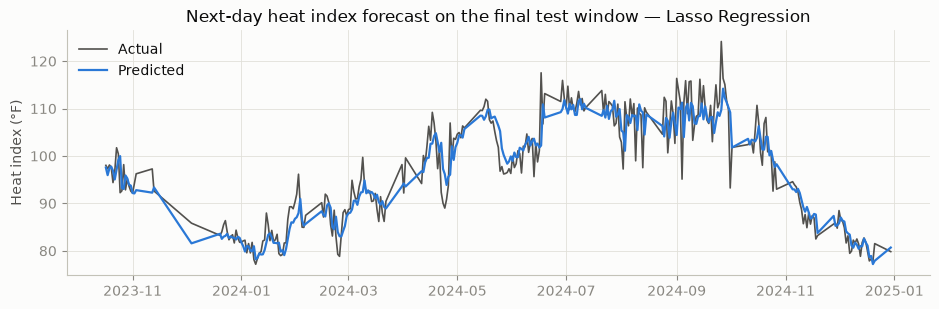

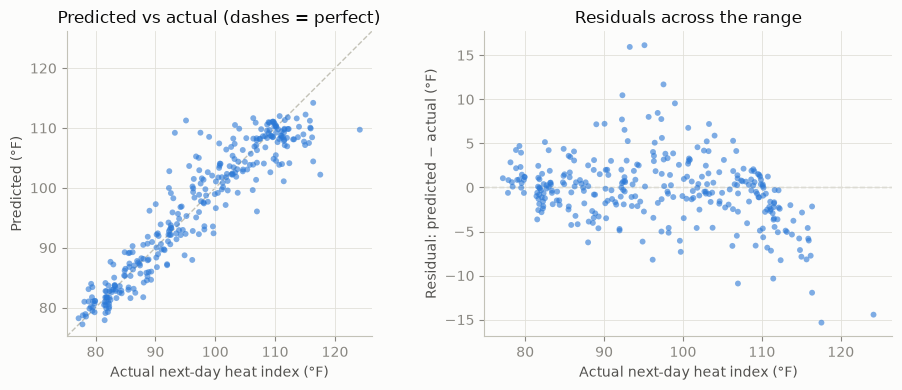

Heat-category agreement on final test days: 71.6%
predicted  cool  warm  hot  very hot
actual                              
cool         94     6    0         0
warm         10    53   15         1
hot           0     8   63        11
very hot      0     0   37        12


In [7]:
import matplotlib.pyplot as plt

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, BLUE = "#e1e0d9", "#c3c2b7", "#2a78d6"
SURFACE = "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlecolor": INK, "font.size": 10,
})

final_model = tuned[best_name]["estimator"]
final_model.fit(X_train_val, y_train_val)  # refit on all non-test data after selection is fixed
pred_test = final_model.predict(X_test)
clim_test = climatology_prediction(test.index, train_val.index.max())

print(f"Final test window: {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)\n")
model_rmse = report_scores(f"{best_name} (final test)", y_test, pred_test)
persist_rmse = report_scores("Persistence (final test)", y_test, X_test["heat_index"])
clim_rmse = report_scores("Climatology (final test)", y_test, clim_test)
print(f"\nForecast skill vs persistence: {1 - model_rmse / persist_rmse:+.1%} RMSE reduction")
print(f"Forecast skill vs climatology: {1 - model_rmse / clim_rmse:+.1%} RMSE reduction")

# Forecast overlay across the final test window.
fig, ax = plt.subplots(figsize=(9.5, 3.2))
ax.plot(y_test.index, y_test, color=INK2, lw=1.2, label="Actual")
ax.plot(y_test.index, pred_test, color=BLUE, lw=1.6, label="Predicted")
ax.set_ylabel("Heat index (°F)")
ax.set_title(f"Next-day heat index forecast on the final test window — {best_name}")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

# Diagnostics: calibration (left) and where in the range the errors live (right).
residuals = pred_test - y_test
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
lims = [min(y_test.min(), pred_test.min()) - 2, max(y_test.max(), pred_test.max()) + 2]
axes[0].plot(lims, lims, color=BASELINE, lw=1, ls="--", zorder=1)
axes[0].scatter(y_test, pred_test, s=18, color=BLUE, alpha=0.6, edgecolors="none", zorder=2)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_aspect("equal")
axes[0].set_xlabel("Actual next-day heat index (°F)")
axes[0].set_ylabel("Predicted (°F)")
axes[0].set_title("Predicted vs actual (dashes = perfect)")

axes[1].axhline(0, color=BASELINE, lw=1, ls="--", zorder=1)
axes[1].scatter(y_test, residuals, s=18, color=BLUE, alpha=0.6, edgecolors="none", zorder=2)
axes[1].set_xlabel("Actual next-day heat index (°F)")
axes[1].set_ylabel("Residual: predicted − actual (°F)")
axes[1].set_title("Residuals across the range")
fig.tight_layout()
plt.show()

# Heat-category labels from the forecast (the notebook's original downstream demo),
# now evaluated as a classification: how often does the forecast land in the right bin?
heat_bins = [-np.inf, 90, 100, 110, np.inf]
heat_labels = ["cool", "warm", "hot", "very hot"]
label_pred = pd.cut(pd.Series(pred_test, index=y_test.index), bins=heat_bins, labels=heat_labels, right=False)
label_true = pd.cut(y_test, bins=heat_bins, labels=heat_labels, right=False)
print(f"Heat-category agreement on final test days: {(label_pred == label_true).mean():.1%}")
print(pd.crosstab(label_true, label_pred, rownames=["actual"], colnames=["predicted"]))


### 6 · What the model actually uses

Permutation importance is computed on the validation window with a model fit only on the training window. That keeps the final test window reserved for final scoring rather than feature interpretation.


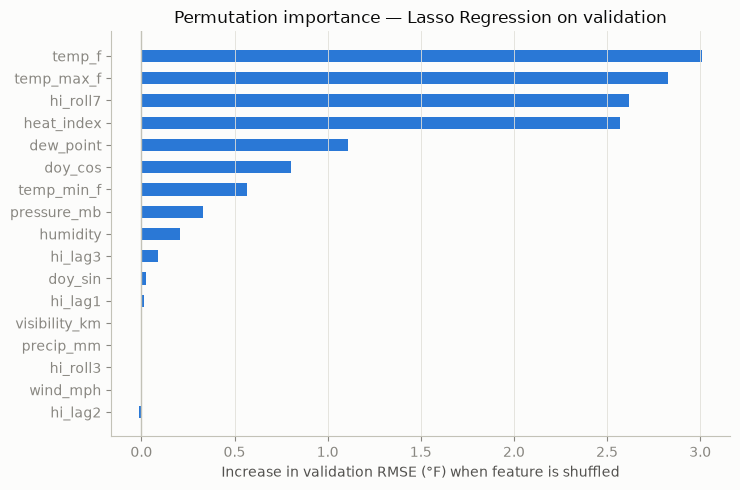

temp_f           3.009
temp_max_f       2.828
hi_roll7         2.619
heat_index       2.568
dew_point        1.110
doy_cos          0.806
temp_min_f       0.566
pressure_mb      0.333
humidity         0.207
hi_lag3          0.092
doy_sin          0.026
hi_lag1          0.016
visibility_km    0.002
precip_mm        0.000
hi_roll3         0.000
wind_mph        -0.001
hi_lag2         -0.011


In [8]:
# Shuffle one feature's validation-window values, measure how much RMSE degrades.
# The diagnostic model is fit on train only so validation remains unseen here.
diagnostic_model = clone(tuned[best_name]["estimator"]).fit(X_train, y_train)
perm = permutation_importance(diagnostic_model, X_val, y_val, n_repeats=20,
                              random_state=random_state, scoring="neg_root_mean_squared_error")
importance = pd.Series(perm.importances_mean, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(importance.index, importance.values, color=BLUE, height=0.55)
ax.axvline(0, color=BASELINE, lw=1)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Increase in validation RMSE (°F) when feature is shuffled")
ax.set_title(f"Permutation importance — {best_name} on validation")
fig.tight_layout()
plt.show()

print(importance.sort_values(ascending=False).round(3).to_string())


### 7 · Serve-time parity check

In production this model's inputs come from the backend's `weather_observation` table (live NWS data), not these CSVs. After the `preston/extend-weather-observation` branch, that table supplies: temperature, humidity, dewpoint (°F), wind speed, pressure, visibility, and precipitation — plus anything derivable from the date. Daily max/min temperature is available too, by aggregating the day's hourly forecast periods. Today's heat index is computable from temperature + humidity with the same `heat_index_f` used here.

What the table **cannot** supply on day one: the heat-index **lag and rolling features**, which need weeks of accumulated per-cell history. This section retunes and compares the full and serve-available feature sets on validation only. The final test is not used to choose a feature set.


In [9]:
parity_cols = ["temp_f", "temp_max_f", "temp_min_f", "humidity", "dew_point", "pressure_mb",
               "visibility_km", "wind_mph", "precip_mm", "heat_index", "doy_sin", "doy_cos"]
dropped_cols = [c for c in feature_cols if c not in parity_cols]
print(f"Serve-parity drops: {dropped_cols}")
print("(these need per-cell heat-index history, which the backend only starts accumulating at launch)\n")

# Reuse the already-tuned full-feature result; only the serve-parity feature set needs
# a fresh tuning pass. Both rows are compared on validation, not final test.
full_winner = tuning_df.iloc[0]["model"]
full_info = tuned[full_winner]
feature_set_results = [{
    "setup": f"{full_winner} (full features)",
    "tuned_cv_rmse": full_info["cv_rmse"],
    "validation_rmse": full_info["val_rmse"],
    "validation_mae": full_info["val_mae"],
}]

parity_tuned, parity_table = tune_model_set(X_train[parity_cols], y_train,
                                            X_val[parity_cols], y_val,
                                            parity_cols, "serve-parity features")
parity_winner = parity_table.iloc[0]["model"]
parity_info = parity_tuned[parity_winner]
feature_set_results.append({
    "setup": f"{parity_winner} (serve-parity features)",
    "tuned_cv_rmse": parity_info["cv_rmse"],
    "validation_rmse": parity_info["val_rmse"],
    "validation_mae": parity_info["val_mae"],
})

feature_set_results.append({"setup": "Persistence baseline", "tuned_cv_rmse": np.nan,
                            "validation_rmse": mean_squared_error(y_val, X_val["heat_index"]) ** 0.5,
                            "validation_mae": mean_absolute_error(y_val, X_val["heat_index"])})
feature_set_results.append({"setup": "Climatology baseline", "tuned_cv_rmse": np.nan,
                            "validation_rmse": mean_squared_error(y_val, clim_val) ** 0.5,
                            "validation_mae": mean_absolute_error(y_val, clim_val)})

parity_df = pd.DataFrame(feature_set_results)
print(parity_df.round(3).to_string(index=False))

full_rmse = parity_df.loc[parity_df["setup"].str.contains("full features"), "validation_rmse"].iloc[0]
parity_rmse = parity_df.loc[parity_df["setup"].str.contains("serve-parity features"), "validation_rmse"].iloc[0]
print(f"\nGoing live before lag history exists costs {parity_rmse - full_rmse:+.3f}F validation RMSE "
      f"({parity_rmse / full_rmse - 1:+.1%}).")


Serve-parity drops: ['hi_lag1', 'hi_lag2', 'hi_lag3', 'hi_roll3', 'hi_roll7']
(these need per-cell heat-index history, which the backend only starts accumulating at launch)

serve-parity features | Linear Regression: tuned CV RMSE=4.419; validation RMSE=4.018; {}
serve-parity features | Ridge Regression: tuned CV RMSE=4.391; validation RMSE=4.033; {'alpha': 3.90796715682288}
serve-parity features | Lasso Regression: tuned CV RMSE=4.420; validation RMSE=4.018; {'alpha': 0.00010221922977737939}
serve-parity features | Elastic Net: tuned CV RMSE=4.401; validation RMSE=4.054; {'alpha': 0.028163255623157798, 'l1_ratio': 0.2770921578887888}
serve-parity features | Random Forest: tuned CV RMSE=4.991; validation RMSE=4.177; {'n_estimators': 469, 'max_depth': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
serve-parity features | Gradient Boosting: tuned CV RMSE=4.889; validation RMSE=4.220; {'n_estimators': 104, 'learning_rate': 0.08300457341142498, 'max_depth': 2, 'subsample': 0.7856665984

/Users/rusli/Documents/GitHub/Rice-To-Meet-You/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/rusli/Documents/GitHub/Rice-To-Meet-You/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/rusli/Documents/GitHub/Rice-To-Meet-You/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/rusli/Documents/GitHub/Rice-To-Meet-You/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximu

serve-parity features | Neural Network (MLP): tuned CV RMSE=9.351; validation RMSE=4.541; {'hidden_layer_sizes': (200,), 'alpha': 0.004764555353386893, 'learning_rate_init': 0.007437603997979575}
serve-parity features | XGBoost: tuned CV RMSE=4.897; validation RMSE=4.110; {'n_estimators': 167, 'learning_rate': 0.04130407596109219, 'max_depth': 2, 'subsample': 0.6338903400362437, 'colsample_bytree': 0.80035424140889, 'reg_lambda': 1.966631762323738}
serve-parity features | LightGBM: tuned CV RMSE=4.964; validation RMSE=4.403; {'n_estimators': 214, 'learning_rate': 0.02946109581381588, 'num_leaves': 31, 'min_child_samples': 27, 'reg_lambda': 0.045164594450094304}
serve-parity features | CatBoost: tuned CV RMSE=4.937; validation RMSE=4.114; {'iterations': 624, 'learning_rate': 0.019063226860146682, 'depth': 4, 'l2_leaf_reg': 1.277176969353851}
                                    setup  tuned_cv_rmse  validation_rmse  validation_mae
         Lasso Regression (full features)          4.314 

### 8 · Live NWS-forecast baseline (accumulates over time)

The strongest baseline isn't in these CSVs: **NWS already publishes tomorrow's forecast**, so this model only earns its place if it adds something beyond that. There's no free archive of what NWS *predicted* on past dates, which means this baseline can't be backtested — it has to be measured going forward.

This cell fetches NWS's hourly forecast for **tomorrow** at a fixed location, reduces it to a daily heat index, and appends one row per day to `data/nws_baseline_log.csv`. Anyone on the team can run it (takes seconds); after a couple of weeks the log supports the real comparison: *model vs NWS vs what actually happened*. The same log later becomes training data for a **forecast-aware model** (NWS's tomorrow forecast as an input feature — available today, so it's not leakage), which is the most promising accuracy upgrade on the roadmap.

The location defaults to Houston because that's where the app serves; KQRH is a hackathon-dataset station used for offline history. The comparison becomes fully apples-to-apples once the model is retrained on a host-city record (or on the backend's accumulating per-cell history).

In [10]:
import json
from datetime import date, timedelta

NWS_LOG_PATH = Path("data/nws_baseline_log.csv")
LAT, LON = 29.7604, -95.3698  # Houston - the FIFA host city the app targets
NWS_HEADERS = {"User-Agent": "RiceToMeetYou model testing", "Accept": "application/geo+json"}

# Prefer requests (bundles its own CA certificates); fall back to urllib so this
# cell has zero extra dependencies on a bare Python.
try:
    import requests

    def nws_get(url):
        response = requests.get(url, timeout=20, headers=NWS_HEADERS)
        response.raise_for_status()
        return response.json()
except ModuleNotFoundError:
    from urllib.request import Request, urlopen

    def nws_get(url):
        with urlopen(Request(url, headers=NWS_HEADERS), timeout=20) as response:
            return json.load(response)

try:
    points = nws_get(f"https://api.weather.gov/points/{LAT},{LON}")
    hourly = nws_get(points["properties"]["forecastHourly"])
    periods = pd.DataFrame([
        {"start": p["startTime"], "temp_f": p["temperature"], "humidity": p["relativeHumidity"]["value"]}
        for p in hourly["properties"]["periods"]
    ])
    periods["start"] = pd.to_datetime(periods["start"])  # NWS sends local-time stamps

    tomorrow = date.today() + timedelta(days=1)
    tomorrow_periods = periods[periods["start"].dt.date == tomorrow]
    if tomorrow_periods.empty:
        raise ValueError("NWS response contained no forecast periods for tomorrow")

    # Reduce tomorrow's 24 hourly forecasts to the two daily numbers worth tracking.
    hi_hourly = heat_index_f(tomorrow_periods["temp_f"], tomorrow_periods["humidity"])
    nws_row = {
        "run_date": date.today().isoformat(),
        "target_date": tomorrow.isoformat(),
        "lat": LAT,
        "lon": LON,
        "nws_hi_daily_max": round(float(np.max(hi_hourly)), 2),
        "nws_hi_daily_mean": round(float(np.mean(hi_hourly)), 2),
    }

    # One row per run date: re-running on the same day overwrites that day's row.
    if NWS_LOG_PATH.exists():
        log = pd.read_csv(NWS_LOG_PATH)
        log = log[log["run_date"] != nws_row["run_date"]]
        log = pd.concat([log, pd.DataFrame([nws_row])], ignore_index=True)
    else:
        log = pd.DataFrame([nws_row])
    log.to_csv(NWS_LOG_PATH, index=False)

    print(f"NWS forecast for tomorrow ({tomorrow}) at Houston: "
          f"max heat index {nws_row['nws_hi_daily_max']}F, daily mean {nws_row['nws_hi_daily_mean']}F")
    print(f"Logged to {NWS_LOG_PATH} - {len(log)} row(s) so far, one per day this cell was run.")
    print("After ~2 weeks: join on target_date against observed weather to score NWS vs model vs reality.")
except Exception as exc:
    print(f"Skipping live NWS fetch (offline or API hiccup - safe to ignore): {exc}")

Skipping live NWS fetch (offline or API hiccup - safe to ignore): <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1081)>


### 9 · Multi-city generalization — the grid-cell situation

Everything above uses one station (KQRH). But in production the model predicts for **grid cells**, and a grid cell is a place the model has never trained on. The honest test for that is a **held-out-city evaluation**: pool training across many stations, keep 20% of cities out of training entirely, and score on future dates only. KQRH stays in the training group so "did pooling help KQRH" is answerable.

The pooled section uses the same validation cutoff as the single-city workflow for model comparison. Treat any later final-test scoring as a locked report, not another selection pass.


In [11]:
# Build the same per-city daily features for every station in the exports.
def build_city_daily(city_frame):
    d = city_frame.set_index("date").asfreq("D")
    d["heat_index"] = heat_index_f(d["temp_f"], d["humidity"])
    for lag in (1, 2, 3):
        d[f"hi_lag{lag}"] = d["heat_index"].shift(lag)
    for window in (3, 7):
        d[f"hi_roll{window}"] = d["heat_index"].rolling(window).mean()
    doy = d.index.dayofyear
    d["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    d["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    d["hi_next_day"] = d["heat_index"].shift(-forecast_horizon_days)
    return d

# Same-city+date conflicts can't fail-fast here the way section 1 does for one city -
# a single bad export line among ~400 stations shouldn't block the whole study - so
# quarantine conflicting keys instead of silently keeping an arbitrary first row.
mc_all = df.sort_values(["city", "date"], kind="stable")
conflict_mask = mc_all.duplicated(subset=["city", "date"], keep=False)
mc_conflicts = int(conflict_mask.sum())
if mc_conflicts:
    conflict_keys = mc_all.loc[conflict_mask, ["city", "date"]].drop_duplicates()
    mc_all = mc_all.merge(conflict_keys.assign(_conflict=True), on=["city", "date"], how="left")
    mc_all = mc_all[mc_all["_conflict"].isna()].drop(columns="_conflict")
    print(f"Quarantined {mc_conflicts} rows from conflicting city+date keys before pooled modeling")

mc_frames = []
for city, group in mc_all.groupby("city"):
    d = build_city_daily(group.drop(columns="city"))
    d["city"] = city
    mc_frames.append(d)
mc_data = pd.concat(mc_frames).dropna(subset=feature_cols + [target_col])
print(f"{mc_data['city'].nunique()} cities, {len(mc_data)} usable day -> next-day samples")

# The validation cutoff is used for pooled model comparison. City holdout is sampled
# after feature construction but before training, and KQRH remains seen by design.
mc_split_date = val.index.min()
rng = np.random.default_rng(random_state)
mc_cities = np.array(sorted(mc_data["city"].unique()))
heldout_cities = set(rng.choice(mc_cities, size=int(len(mc_cities) * 0.2), replace=False))
heldout_cities.discard(city_filter)

mc_train = mc_data[(mc_data.index < mc_split_date) & ~mc_data["city"].isin(heldout_cities)]
mc_future = mc_data[mc_data.index >= mc_split_date]
mc_slices = {
    "seen cities, validation/future dates": mc_future[~mc_future["city"].isin(heldout_cities)
                                                       & (mc_future["city"] != city_filter)],
    "UNSEEN cities, validation/future dates": mc_future[mc_future["city"].isin(heldout_cities)],
    f"{city_filter}, validation/future dates": mc_future[mc_future["city"] == city_filter],
}
print(f"pooled train: {len(mc_train)} samples from {mc_train['city'].nunique()} cities "
      f"(before {mc_split_date.date()})")
for name, eval_slice in mc_slices.items():
    print(f"eval [{name}]: {len(eval_slice)} samples, {eval_slice['city'].nunique()} cities")


401 cities, 585958 usable day -> next-day samples
pooled train: 260630 samples from 321 cities (before 2022-10-15)
eval [seen cities, validation/future dates]: 208173 samples, 320 cities
eval [UNSEEN cities, validation/future dates]: 51931 samples, 80 cities
eval [KQRH, validation/future dates]: 620 samples, 1 cities


/Users/rusli/Documents/GitHub/Rice-To-Meet-You/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.994358e+06, tolerance: 1.222e+04
  model = cd_fast.enet_coordinate_descent(


Validation/future RMSE (F) by evaluation slice:
                            eval slice   days  pooled Lasso Regression  pooled Hist Gradient Boosting  persistence
  seen cities, validation/future dates 208173                    5.828                          5.596        6.415
UNSEEN cities, validation/future dates  51931                    5.827                          5.656        6.401
         KQRH, validation/future dates    620                    5.335                          4.921        4.410

For reference, the single-city Lasso Regression from section 5 scored final-test RMSE=3.877 on KQRH's lockbox future dates.

pooled Hist Gradient Boosting across 80 unseen cities (>=30 eval days each):
median skill vs persistence +13.1%; beats persistence in 91% of cities

Weakest 5 cities (candidates for a closer look at their raw data):
      days  model_rmse  persist_rmse  skill
city                                       
KQGX   624       8.370         5.874 -0.425
KUIL   652       4

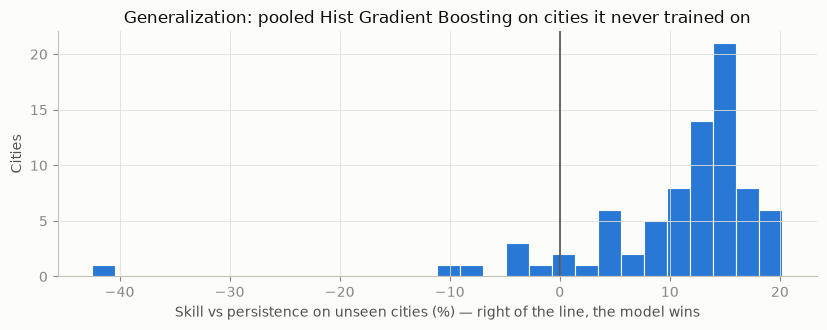

In [12]:
# Two pooled models. The single-city tuned winner is reused as-is (its hyperparameters
# were not tuned for pooled data, so its pooled score is a pessimistic floor). HistGradientBoosting
# joins as the nonlinear challenger: it handles heterogeneous cities natively and stays fast.
pooled_models = {
    f"pooled {best_name}": clone(final_model),
    "pooled Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=random_state),
}
for name, model in pooled_models.items():
    model.fit(mc_train[feature_cols], mc_train[target_col])

mc_rows = []
for slice_name, eval_slice in mc_slices.items():
    row = {"eval slice": slice_name, "days": len(eval_slice)}
    for name, model in pooled_models.items():
        row[name] = mean_squared_error(eval_slice[target_col], model.predict(eval_slice[feature_cols])) ** 0.5
    row["persistence"] = mean_squared_error(eval_slice[target_col], eval_slice["heat_index"]) ** 0.5
    mc_rows.append(row)

mc_results = pd.DataFrame(mc_rows)
print("Validation/future RMSE (F) by evaluation slice:")
print(mc_results.round(3).to_string(index=False))
print(f"\nFor reference, the single-city {best_name} from section 5 scored final-test RMSE={model_rmse:.3f} "
      f"on {city_filter}'s lockbox future dates.")

# Per-city view on the cities the model never saw - the production situation.
unseen_name = next(n for n in mc_slices if n.startswith("UNSEEN"))
best_pooled_name = min(pooled_models,
                       key=lambda n: mc_results.loc[mc_results["eval slice"] == unseen_name, n].iloc[0])
best_pooled = pooled_models[best_pooled_name]

unseen = mc_slices[unseen_name].copy()
unseen["pred"] = best_pooled.predict(unseen[feature_cols])
city_stats = []
for city, group in unseen.groupby("city"):
    if len(group) < 30:  # too few eval days for a stable per-city RMSE
        continue
    city_stats.append({
        "city": city, "days": len(group),
        "model_rmse": mean_squared_error(group[target_col], group["pred"]) ** 0.5,
        "persist_rmse": mean_squared_error(group[target_col], group["heat_index"]) ** 0.5,
    })
per_city = pd.DataFrame(city_stats).set_index("city")
per_city["skill"] = 1 - per_city["model_rmse"] / per_city["persist_rmse"]

beats = (per_city["skill"] > 0).mean()
print(f"\n{best_pooled_name} across {len(per_city)} unseen cities (>=30 eval days each):")
print(f"median skill vs persistence {per_city['skill'].median():+.1%}; beats persistence in {beats:.0%} of cities")
print("\nWeakest 5 cities (candidates for a closer look at their raw data):")
print(per_city.sort_values("skill").head(5).round(3).to_string())

# Distribution of that skill: one series, so the notebook's standard blue carries it;
# the zero line is the pass/fail boundary, drawn in ink rather than a status color.
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.hist(per_city["skill"] * 100, bins=30, color=BLUE, edgecolor=SURFACE, linewidth=0.8)
ax.axvline(0, color=INK2, lw=1.2)
ax.set_xlabel("Skill vs persistence on unseen cities (%) — right of the line, the model wins")
ax.set_ylabel("Cities")
ax.set_title(f"Generalization: {best_pooled_name} on cities it never trained on")
fig.tight_layout()
plt.show()
